# UpSet (static)

> UpSet plot (any number of sets): intersection bars, dot matrix and set totals, with members listed inside each bar.

In [1]:
#| default_exp upset

In [2]:
#| export
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_contents
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#| export
def upset(data_dict, color_list=None, bar_width=0.8, totals_bar_height=0.6,
          matrix_height=1.0, intersection_plot_elements=6, totals_plot_elements=2,
          circle_size=100, gridkey_fontsize=13, axis_fontsize=13, fontsize=None,
          count_fontsize=12, count_color=None, min_fontsize=6, max_fontsize=20,
          figsize=None, font="Inter", sort_by="cardinality",
          wspace=0, hspace=0, title="", title_fontsize=20, title_fontweight="bold", save_path=None):
    
    #increasing total plots elements means the horizontal barplots grow longer
    #circle size is marker size, do NOT use element size here. using that will mess with figsize
    # wspace controls the distance between horizontal barplots and gridkey; hspace - white space between vertical bar plots and gridkey
    # matrix height: thickness of the matrix below
    # color_list: a list of colors, or the name of a matplotlib colormap (e.g. "Dark2") sampled to the number of bars --> not in list object
    
    data_dict = {k: (v.iloc[:, 0].tolist() if isinstance(v, pd.DataFrame) else list(v)) for k, v in data_dict.items()}
    matrix = from_contents(data_dict)
    member_font = ["IBM Plex Mono", "monospace"]  # member lists inside the bars stay monospace
    obj = UpSet(matrix, element_size=None, show_counts=True, sort_by=sort_by,
                intersection_plot_elements=intersection_plot_elements,
                totals_plot_elements=totals_plot_elements)
    fig = plt.figure(figsize=figsize if figsize else (19, 10))
    axes = obj.plot(fig=fig)
    fig.subplots_adjust(hspace=hspace, wspace=wspace)
    ax_int, ax_mat, ax_tot = axes["intersections"], axes["matrix"], axes["totals"]
    count_texts = list(ax_int.texts)

    if matrix_height != 1.0:
        scale_axes = [ax_mat, ax_tot]
        if "shading" in axes:
            scale_axes.append(axes["shading"])
        for ax in scale_axes:
            pos = ax.get_position()
            new_h = pos.height * matrix_height
            ax.set_position([pos.x0, pos.y0 + pos.height - new_h, pos.width, new_h])

    ax_mat.tick_params(axis="y", labelsize=gridkey_fontsize)
    plt.setp(ax_mat.get_yticklabels(), fontfamily=font)
    plt.setp(ax_tot.get_xticklabels(), fontfamily=font)
    ax_int.yaxis.label.set_size(axis_fontsize)
    ax_int.yaxis.label.set_fontfamily(font)
    ax_int.tick_params(axis="y", labelsize=axis_fontsize)
    plt.setp(ax_int.get_yticklabels(), fontfamily=font)
    sizes = obj.intersections
    n_bars = len(sizes)

    if isinstance(color_list, str):
        cmap = plt.get_cmap(color_list)
        base = cmap.colors if hasattr(cmap, "colors") else [cmap(k / max(n_bars - 1, 1)) for k in range(n_bars)]
        color_list = [base[k % len(base)] for k in range(n_bars)]

    if color_list is not None and len(color_list) != n_bars:
        print(f"Number of colors given ({len(color_list)}) does not match the number of bar plots ({n_bars})")
        return

    bars = [p for p in ax_int.patches if isinstance(p, plt.Rectangle)]
    text_color = "white" if color_list is None else "black"
    for j, bar in enumerate(bars):
        center = bar.get_x() + bar.get_width() / 2
        bar.set_width(bar_width)
        bar.set_x(center - bar_width / 2)
        bar.set_facecolor("black" if color_list is None else color_list[j])

    for bar in ax_tot.patches:
        if isinstance(bar, plt.Rectangle):
            center = bar.get_y() + bar.get_height() / 2
            bar.set_height(totals_bar_height)
            bar.set_y(center - totals_bar_height / 2)

    for coll in ax_mat.collections:
        if hasattr(coll, "set_sizes"):
            coll.set_sizes([circle_size])
        coll.set_linewidth(0.12 * (circle_size ** 0.5) * 1.4)

    if color_list is not None:
        for coll in ax_mat.collections:
            offsets = coll.get_offsets()
            fc = coll.get_facecolors()
            if len(fc) == 0 or fc[0][:3].mean() > 0.5:
                continue
            new = np.array([mpl.colors.to_rgba(color_list[min(max(int(round(x)), 0), n_bars - 1)]) for x, _ in offsets])
            coll.set_facecolor(new)

    gene_lists = []
    for subset_key in sizes.index:
        mask = True
        for cat_name, is_present in zip(sizes.index.names, subset_key):
            mask &= (matrix.index.get_level_values(cat_name) == is_present)
        genes = matrix[mask]
        gene_lists.append([str(g[0]) if isinstance(g, (list, np.ndarray)) else str(g) for g in genes.values])

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bar_bot_px = ax_int.transData.transform((0, 0))[1]
    bar_h_px = [ax_int.transData.transform((0, s))[1] - bar_bot_px for s in sizes]
    col_px = ax_int.transData.transform((1, 0))[0] - ax_int.transData.transform((0, 0))[0]
    bar_w_px = col_px * bar_width
    all_genes = [g for gl in gene_lists for g in gl]
    longest = max(all_genes, key=len) if all_genes else "Ag"

    dummy = ax_int.text(0, 0, longest, fontfamily=member_font)
    if fontsize is not None:
        fs = fontsize
        dummy.set_fontsize(fs)
        bbox = dummy.get_window_extent(renderer)
        text_h = bbox.height
    else:
        fs, text_h = min_fontsize, 0
        for cand in range(max_fontsize, min_fontsize - 1, -1):
            dummy.set_fontsize(cand)
            bbox = dummy.get_window_extent(renderer)
            h, w = bbox.height, bbox.width
            if w <= bar_w_px and all(len(gl) * h <= bh for gl, bh in zip(gene_lists, bar_h_px) if gl):
                fs, text_h = cand, h
                break
        if text_h == 0:
            dummy.set_fontsize(min_fontsize)
            text_h = dummy.get_window_extent(renderer).height
    dummy.remove()

    plt.setp(count_texts, fontweight="bold", fontfamily=font,
             fontsize=count_fontsize if count_fontsize is not None else fs)
    if count_color is not None:
        plt.setp(count_texts, color=count_color)
    elif color_list is not None:
        for txt, c in zip(count_texts, color_list):
            txt.set_color([v * 0.6 for v in mpl.colors.to_rgb(c)])

    inv = ax_int.transData.inverted()
    for i, gl in enumerate(gene_lists):
        if not gl:
            continue
        n = len(gl)
        H = bar_h_px[i]
        gap = (H - n * text_h) / (n + 1)
        top_center = bar_bot_px + H - gap - text_h / 2
        ys_px = [top_center - j * (gap + text_h) for j in range(n)]
        for j, g in enumerate(gl):
            y_data = inv.transform((0, ys_px[j]))[1]
            ax_int.text(i, y_data, g, ha="center", va="center", fontsize=fs, color=text_color, fontfamily=member_font, zorder=10)

    fig.suptitle(title, fontsize=title_fontsize, fontweight=title_fontweight, fontfamily=font)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [4]:
#| hide
from matplotlib import font_manager
import matplotlib.pyplot as plt
for f in font_manager.findSystemFonts(fontpaths=["Font" if __import__("os").path.isdir("Font") else "../Font"]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "IBM Plex Mono"

## Data

UpSet takes a plain `{name: [members]}` dict.

In [5]:
drugbase = ("Drug target sample files/" if __import__("os").path.isdir("Drug target sample files") else "../Drug target sample files/")
flu = pd.read_csv(drugbase + "1. FLUOXETINE_sample.csv")["Gene names"].dropna().tolist()
ibu = pd.read_csv(drugbase + "2. IBUPROFEN_sample.csv")["Gene names"].dropna().tolist()
acet = pd.read_csv(drugbase + "3. ACETAMINOPHEN_sample.csv")["Gene names"].dropna().tolist()

## Static UpSet

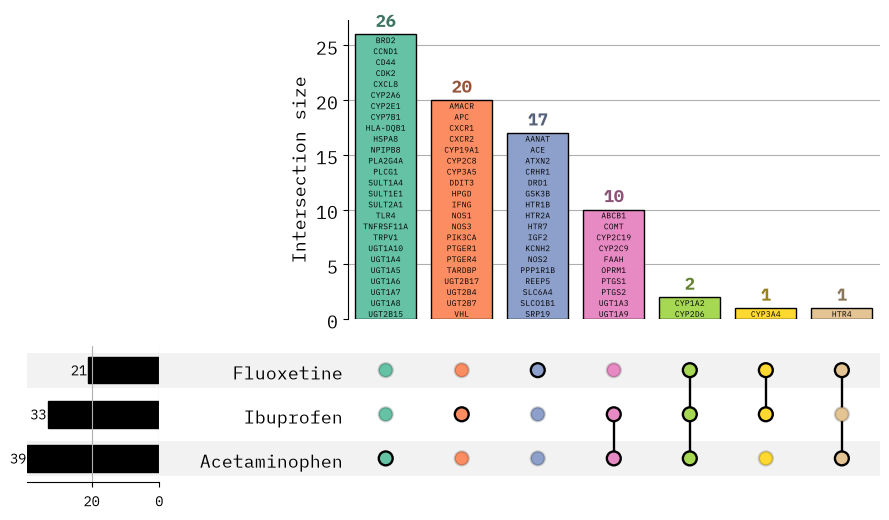

In [6]:
upset({"Fluoxetine": flu, "Ibuprofen": ibu, "Acetaminophen": acet}, figsize=(11, 6), color_list="Set2", wspace=0.55)

## Controlling plot aesthetics

| Argument | Controls |
|---|---|
| `color_list` | list of bar colours, or a colormap name (e.g. `"Set2"`); one per intersection bar |
| `title`, `title_fontsize` | figure title text and size |
| `count_color`, `count_fontsize` | colour and size of the count above each bar (default colour: a darkened bar colour) |
| `fontsize` | force a fixed member font (default: auto-fit to the bars) |
| `min_fontsize`, `max_fontsize` | bounds for the automatic font search |
| `circle_size` | size of the dot-matrix markers |
| `gridkey_fontsize`, `axis_fontsize` | font sizes of the set names and the axes |
| `bar_width`, `totals_bar_height` | thickness of the intersection and set-total bars |
| `sort_by` | order bars by `"cardinality"` or `"degree"` |
| `wspace`, `hspace` | spacing between the panels |
| `figsize`, `save_path` | figure size, and an optional path to save a 300-dpi PNG |

**Colormap names.** Any Matplotlib colormap name works for `color_list`; qualitative maps keep the sets/bars most distinct: `Set1`, `Set2`, `Set3`, `Dark2`, `Paired`, `Accent`, `Pastel1`, `Pastel2`, `tab10`, `tab20`. You can also pass an explicit list of colours instead.